In [5]:
import numpy as np
from scipy.integrate import solve_ivp


# ----------------------------
# Template dynamics R(t): Eq. (11)
# ----------------------------
def R_of_t(t, p):
    R0 = p["R0"]
    R02 = p.get("R02", 0.0)
    r = p["r"]
    d_R = p["d_R"]
    T_off = p["T_off"]
    T_boost = p.get("T_boost", np.inf)
    T_off2 = p.get("T_off2", 0.0)

    # Primary: growth then decay
    if t < T_off:
        R_primary = R0 * np.exp(r * t)
    else:
        R_primary = R0 * np.exp(r * T_off) * np.exp(-d_R * (t - T_off))

    # Booster: 0 before T_boost, then growth then decay
    if t < T_boost:
        R_boost = 0.0
    else:
        if t < (T_boost + T_off2):
            R_boost = R02 * np.exp(r * (t - T_boost))
        else:
            R_boost = R02 * np.exp(r * T_off2) * np.exp(-d_R * (t - (T_boost + T_off2)))

    return R_primary + R_boost


# ----------------------------
# ODE RHS: Eqs (1)-(9)
# ----------------------------
def rhs(t, y, p):
    """
    State ordering:
      y = [B1..B8, P, PL, M, Mstar, A, Ag]  total dimension = 14
    """
    B = y[0:8]
    P = y[8]
    PL = y[9]
    M = y[10]
    Mstar = y[11]
    A = y[12]
    Ag = y[13]

    # Saturation terms
    s_B = Ag / (p["K"] + Ag + 1e-12)              # used in (1)-(3)
    Km_mem = p["K"] / p["mM"]                     # half-max constant is K/mM
    s_M = Ag / (Km_mem + Ag + 1e-12)              # used in (6)-(7)

    dB = np.zeros_like(B)

    # (1)
    dB[0] = p["r1"] * s_B * B[0] - p["phi"] * B[0] - p["d_B"] * B[0]

    # (2) n=2..7
    # B_prev = B1..B6, B_mid = B2..B7
    B_prev = B[0:6]
    B_mid = B[1:7]
    dB[1:7] = (
        p["r1"] * s_B * B_mid
        + p["phi"] * B_prev
        - p["phi"] * B_mid
        - p["d_B"] * B_mid
    )

    # (3)
    dB[7] = p["r2"] * s_B * B[7] + p["phi"] * B[6] - (p["mu"] + p["pi"] + p["d_B"]) * B[7]

    # (4)
    dP = p["pi"] * B[7] + p["pi2"] * Mstar - (p["d_P"] + p["lambd"]) * P

    # (5)
    dPL = p["lambd"] * P - p["d_L"] * PL

    # (6)
    dM = (
        p["mu"] * B[7]
        + p["mu2"] * Mstar
        + p["rM_minus_dM"] * M
        - p["fM"] * s_M * M
    )

    # (7)
    dMstar = (
        p["fM"] * s_M * M
        + p["r2"] * s_M * Mstar
        - (p["mu2"] + p["pi2"] + p["d_B"]) * Mstar
    )

    # (8)
    dA = p["theta_P"] * P + p["theta_B"] * B[7] + p["theta_L"] * PL - p["d_A"] * A

    # (9)
    R = R_of_t(t, p)
    prod = p["k_t"] * (R / (p["K_R"] + R + 1e-12))
    dAg = prod - p["d_Ag"] * Ag - p["k_b"] * Ag * A

    return np.concatenate([dB, np.array([dP, dPL, dM, dMstar, dA, dAg])])


def example_params():
    return dict(
        r1=2.5, r2=4.0, phi=0.27, d_B=0.14, pi=0.023, mu=0.050,
        d_P=0.35, lambd=0.0058, d_L=0.0032, rM_minus_dM=-0.011, fM=0.95,
        pi2=1.8, mu2=4.1, mM=3237.0,
        theta_P=1.2e7, theta_L=1.2e7, theta_B=0.01 * 1.2e7, d_A=0.033,
        K=1.0, k_t=3255.0, K_R=1.0, d_Ag=0.2, k_b=1e-3,
        R0=1.0, R02=0.5, r=0.2, d_R=0.3, T_off=10.0, T_boost=30.0, T_off2=5.0,
    )


if __name__ == "__main__":
    p = example_params()

    B0 = 1.0
    y0 = np.array(
        [B0, 0, 0, 0, 0, 0, 0, 0,   # B1..B8
         0, 0,                      # P, PL
         0, 0,                      # M, M*
         0, 0],                     # A, Ag
        dtype=float
    )

    t0, t1 = 0.0, 300.0
    t_eval = np.linspace(t0, t1, 301)  # daily output

    # Stiff solvers: "Radau" or "BDF" are usually best here
    sol = solve_ivp(
        fun=lambda t, y: rhs(t, y, p),
        t_span=(t0, t1),
        y0=y0,
        method="BDF",
        t_eval=t_eval,
        rtol=1e-6,
        atol=1e-4,
        max_step=np.inf,   # we can set e.g. 0.5 if we want to force resolution
    )

    print("success:", sol.success)
    print("message:", sol.message)
    print("t:", sol.t.shape, "y:", sol.y.shape)  # y is (14, n_times)

    # Example access:
    A = sol.y[12, :]
    Ag = sol.y[13, :]


success: True
message: The solver successfully reached the end of the integration interval.
t: (301,) y: (14, 301)


/tmp/ipykernel_9840/1237440498.py:6: RuntimeWarning: divide by zero encountered in log10
  A = np.log10(sol.y[12, :])   # antigen
/tmp/ipykernel_9840/1237440498.py:11: RuntimeWarning: divide by zero encountered in log10
  Mstar = np.log10(sol.y[11, :])
/tmp/ipykernel_9840/1237440498.py:11: RuntimeWarning: invalid value encountered in log10
  Mstar = np.log10(sol.y[11, :])


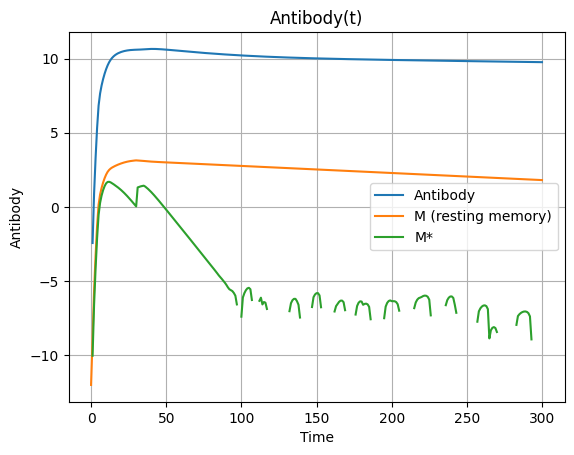

In [6]:
import matplotlib.pyplot as plt

# After solve_ivp(...)
# sol.y has shape (14, n_times) with the state order:
# [B1..B8, P, PL, M, Mstar, A, Ag]
A = np.log10(sol.y[12, :])   # antigen
t  = sol.t
Mem_rest = sol.y[10, :]          # M
Mem_total = sol.y[10, :] + sol.y[11, :]   # M + Mstar
M = np.log10(sol.y[10, :] + 1e-12)
Mstar = np.log10(sol.y[11, :])

plt.figure()
plt.plot(t, A, label="Antibody")
plt.plot(t, M, label="M (resting memory)")
plt.plot(t, Mstar, label="M*")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Antibody")
plt.title("Antibody(t)")
plt.grid(True)
plt.show()
